## Plotting the curl of magnetization for different polygons

In [139]:
import numpy as np
from scipy.ndimage import label
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit


import os
import sys

In [140]:
def calc_curl(vector_list):
    vector_list = np.where(vector_list == 0, np.nan, vector_list)
    vector_list = np.rot90(vector_list)
    x_vec = vector_list[:,:,1]
    y_vec = vector_list[:,:,0]
    dy_dx = np.gradient(y_vec, axis=0)
    dx_dy = np.gradient(x_vec, axis=1)
    curl = dy_dx - dx_dy
    curl = np.rot90(np.where(np.isnan(curl), 0, curl), k=3)
    return curl

In [141]:


def number_of_dommain_walls(curl_vec):
  trehshold_vec = curl_vec[curl_vec>0.0]
  labeled_wall, num_walls = label(curl_vec)
  return labeled_wall

In [142]:

def total_curl(plot=False):
  total_curl_list = []
  sides = []
  for root, dir, files in os.walk('masked_shapes'):
    print(files)
    for file in files:
      if file.split(".")[-1] == "npy":
        print(file.split())
        side = file.split(".")[0]
        print(side)
        sides.append(int(side))
        vector_field = np.squeeze((np.load(root+"/"+file)))
        print(vector_field.shape)
        print(vector_field.T[-1])
        total_curl_list.append(np.sum(np.abs(calc_curl(vector_field))))
        if plot:
          plt.imshow(calc_curl(vector_field))
          plt.show()
  sorted_sides, sorted_total_curl_list = zip(*sorted(zip(sides, total_curl_list)))
  return sorted_sides, sorted_total_curl_list

In [143]:
def calculate_mask_area(data):
    shape = np.any(data != 0, axis=2)
    area = np.sum(shape)
    return area

In [144]:
def average_curl(folder = "masked_shapes/",plot=False):
    total_curl_list = []
    sides = []
    
    for root, dir, files in os.walk(folder):
        for file in files:
            if file.split(".")[-1] == "npy":
                side = file.split(".")[0]
                sides.append(int(side))
                vector_field = np.squeeze((np.load(root+'/'+file))) 
                area = calculate_mask_area(vector_field)
                total_curl_list.append(np.sum(np.abs(calc_curl(vector_field)))/area)
                #total_curl_list.append(1/area)
                if plot:
                    plt.imshow(calc_curl(vector_field))
                    plt.show()
    sorted_sides, sorted_total_curl_list = zip(*sorted(zip(sides, total_curl_list)))
    return sorted_sides, sorted_total_curl_list

(np.float64(0.0998981946732843), np.float64(0.22528376942457984), np.float64(0.17161418388204872), np.float64(0.19559033203964846), np.float64(0.16945709340949597), np.float64(0.18268161126351815), np.float64(0.15401261375552314))
7 6


C:\Users\kohlc\AppData\Local\Temp\ipykernel_17948\3607220359.py:2: RuntimeWarning: overflow encountered in exp
  return L * np.exp(-k*(x-x0))


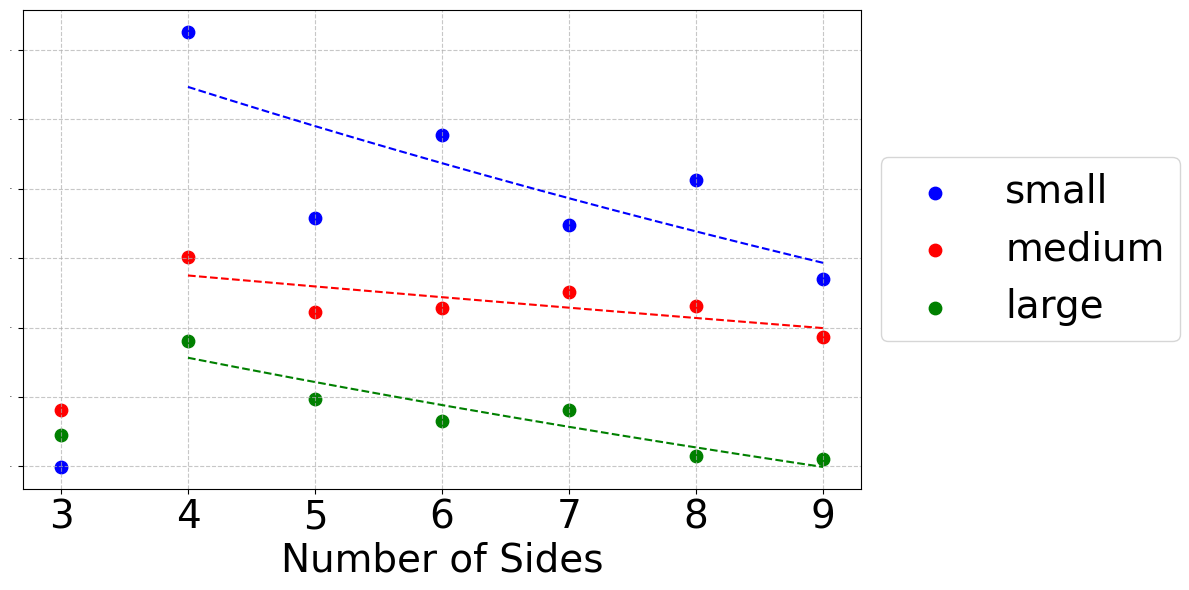

(np.float64(0.10896849641811104), np.float64(0.13613650830977556), np.float64(0.1194714773440384), np.float64(0.1132101683834635), np.float64(0.11616942885560204), np.float64(0.10303573708116334), np.float64(0.1019771408808635))


In [169]:



def exponential_decay_func(x,L,k,x0):
    return L * np.exp(-k*(x-x0))

sides, curl_list = average_curl("masked_smaller") #total_curl(True)
curl_tot = np.array(curl_list)/3

print(curl_list)

popt, _ = curve_fit(exponential_decay_func, sides[1:], curl_list[1:])#, p0=[max(curl_list), 1, np.median(sides)])

x_smooth = np.linspace(min(sides[1:]), max(sides), 500)
y_smooth = exponential_decay_func(x_smooth, *popt)

plt.figure(figsize=(12, 6))
plt.scatter(sides, curl_list, color='b', label='small', s=80)
plt.plot(x_smooth, y_smooth, color='b', linestyle='--')

def logistic_func(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def linear_fit(x, a, b):
    return a*x + b


#def sigmoid(x):
#    return 0.012 *1.01 * (1/(1+np.exp(1.2*(x-6)))) +0.055

def sigmoid(x):
    return 0.012 *1.01 * 2 * (1/(1+np.exp(1.2*(x-6)))) +0.06

#def sigmoid(x):
#    return 0.012 *0.1 * (1/(1+np.exp(1.2*(x-6)))) +0.0625


print(len(sides), len(sides[1:]) )

popt, _ = curve_fit(exponential_decay_func, sides[1:], curl_list[1:])#, p0=[max(curl_list), 1, np.median(sides)])

x_smooth = np.linspace(min(sides[1:]), max(sides), 500)
y_smooth = exponential_decay_func(x_smooth, *popt)

# plt.plot(x_smooth, y_smooth, color='b', linestyle='--', label='exponential fit')

#medium plot
sides, curl_list = average_curl("masked_medium") 
curl_tot += np.array(curl_list)/3

plt.scatter(sides, curl_list, color='r', label='medium', s=80)
popt, _ = curve_fit(exponential_decay_func, sides[1:], curl_list[1:])#, p0=[max(curl_list), 1, np.median(sides)])
x_smooth = np.linspace(min(sides[1:]), max(sides), 500)
y_smooth = exponential_decay_func(x_smooth, *popt)
plt.plot(x_smooth, y_smooth, color='r', linestyle='--')

#Largest plot
sides, curl_list = average_curl() 
curl_tot += np.array(curl_list)/3
plt.scatter(sides, curl_list, color='g', label='large', s=80)
def sigmoid(x):
    return 0.012 *1.01 * (1/(1+np.exp(1.2*(x-6)))) +0.055
popt, _ = curve_fit(exponential_decay_func, sides[1:], curl_list[1:])
x_smooth = np.linspace(min(sides[1:]), max(sides), 500)
y_smooth = exponential_decay_func(x_smooth, *popt)
# y_smooth = sigmoid(x_smooth)

plt.plot(x_smooth, y_smooth, color='g', linestyle='--')

# popt, _ = curve_fit(exponential_decay_func, sides[1:], curl_tot[1:])
# plt.plot(x_smooth, y_smooth, color='r', linestyle='--', label='Trend for all')



plt.xlabel("Number of Sides", fontsize=28)
# plt.ylabel("Curl Flux", fontsize=28)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize =28)
plt.xticks(fontsize=28)
plt.yticks(fontsize=0)
# plt.gca().get_yaxis().set_visible(True)
plt.grid(True)

#plt.ylim(0.05, max(curl_list) * 1.2)


plt.tight_layout()
plt.savefig("Trend_total.png", dpi=300)
plt.show()

print(curl_list)

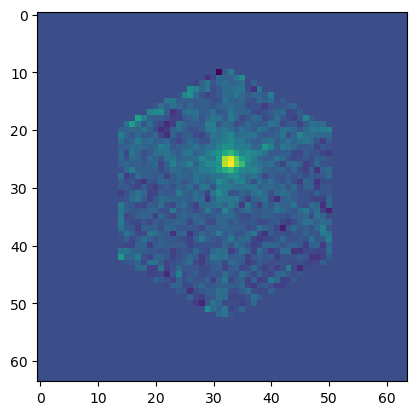

In [146]:
hexagon = np.load('masked_shapes/6.npy')
hexagon = np.where(hexagon == 0, np.nan, hexagon)
hexagon_curl = calc_curl(hexagon)
plt.imsave("raw_hexagon.png", hexagon_curl, cmap='Greens')
plt.imshow(hexagon_curl)
plt.savefig("curl_hexagon.png")

plt.show()

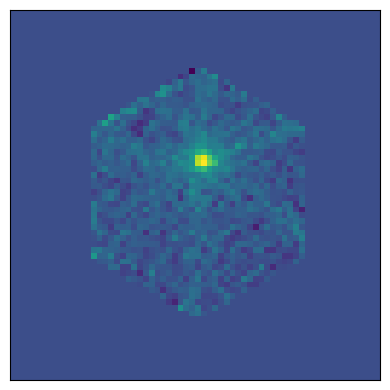

In [147]:
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.set_yticks([])
ax.set_xticks([])

ax.imshow(hexagon_curl)
fig.tight_layout()
plt.savefig("raw_hexagon", dpi=200)

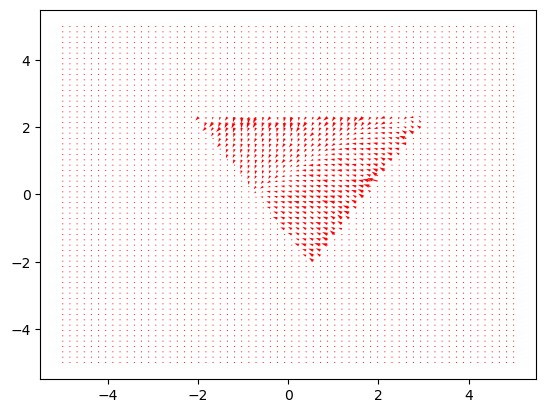

In [148]:
triangle = np.load('masked_shapes/3.npy')
x = np.linspace(-5, 5, triangle.shape[0])
y = np.linspace(-5, 5, triangle.shape[1])
plt.quiver(x, y, triangle[:,:,0], triangle[:,:,1], color='r', scale=100)